
# 03. Иерархическая модель дефицитов и анемии

## Зачем нужен этот этап

В `02_model_baselines.ipynb` мы сравнили четыре direct multiclass baseline:

- `L1_full`
- `L1_compact`
- `CatBoost_full`
- `CatBoost_compact`

Лучший OOF результат показала **L1_full**:

- Macro-F1 ≈ **0.865**
- Balanced Accuracy ≈ **0.870**
- Accuracy ≈ **0.866**

Compact feature set не улучшил качество, поэтому на этом этапе мы **не сокращаем признаки искусственно**.

Теперь переходим к архитектуре, которая лучше соответствует медицинской логике задачи.

Вместо:

```text
37 признаков
    ↓
одна модель
    ↓
один из 12 классов
```

строим:

```text
анализы
   │
   ├── anemia = детерминированное правило Hb + пол
   │
   ├── P(iron deficiency)
   ├── P(B12 deficiency)
   ├── P(folate deficiency)
   ├── P(B6 deficiency)
   ├── P(copper deficiency)
   └── P(inflammation anemia)
              │
              ▼
       сборка anemia_class
       и deficiency_cause
```

Такой подход:

1. лучше соответствует структуре исходных target;
2. естественно поддерживает `mixed_deficiency`;
3. позволяет независимо калибровать вероятность каждого дефицита;
4. позже позволяет добавить rule-based слой;
5. даёт более понятное объяснение результата.



## Важное решение по валидации

Как и раньше, используем только **out-of-fold predictions**.

Для каждого бинарного target:

- outer validation никогда не участвует в preprocessing;
- для L1 параметр `C` выбирается во внутренней CV;
- CatBoost использует фиксированные параметры baseline;
- порог классификации пока равен `0.5`.

Подбор индивидуальных порогов и calibration будет следующим этапом.


In [1]:

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    balanced_accuracy_score,
    average_precision_score,
    roc_auc_score,
    log_loss,
    classification_report,
    ConfusionMatrixDisplay,
)

try:
    from catboost import CatBoostClassifier
except ImportError as exc:
    raise ImportError(
        "Не установлен catboost. "
        "Установи: pip install catboost"
    ) from exc

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5
C_GRID = np.logspace(-4, 0, 9)

print("Импорты выполнены.")


Импорты выполнены.


## 1. Загружаем исходный датасет

In [2]:

def find_dataset():
    candidates = [
        Path("data/raw/deficiency_anemia.csv"),
        Path("../data/raw/deficiency_anemia.csv"),
        Path("deficiency_anemia.csv"),
        Path("data/raw/(СУ)deficiency_anemia (2).csv"),
        Path("../data/raw/(СУ)deficiency_anemia (2).csv"),
        Path("(СУ)deficiency_anemia (2).csv"),
    ]

    for path in candidates:
        if path.exists():
            return path.resolve()

    for root in [Path.cwd(), Path.cwd().parent]:
        matches = list(root.glob("**/*deficiency_anemia*.csv"))
        if matches:
            return matches[0].resolve()

    raise FileNotFoundError(
        "CSV deficiency_anemia не найден."
    )


DATA_PATH = find_dataset()
df = pd.read_csv(DATA_PATH)

print("Файл:", DATA_PATH)
print("Размер:", df.shape)
display(df.head())


Файл: /home/sinopah/meditron/data/raw/deficiency_anemia.csv
Размер: (840, 48)


,patient_id,age_years,sex,hemoglobin,RBC,hematocrit,MCV,MCH,MCHC,RDW,...,anemia,iron_deficiency,B12_deficiency,folate_deficiency,B6_deficiency,copper_deficiency,inflammation_anemia,mixed_deficiency,anemia_class,deficiency_cause
0,P000001,64,M,139.6,4.99,41.8,83.3,28.0,332.5,13.3,...,0,0,1,0,0,0,0,0,B12_deficiency_no_anemia,B12_deficiency
1,P000002,52,F,122.3,3.87,35.5,90.0,31.6,343.7,19.8,...,0,0,0,1,0,0,0,0,folate_deficiency_no_anemia,folate_deficiency
2,P000003,43,F,144.9,5.20,44.6,86.1,27.9,329.2,14.7,...,0,1,0,0,0,0,0,0,latent_deficiency,iron_deficiency
3,P000004,26,F,121.7,4.46,39.0,86.9,27.3,316.2,16.7,...,0,0,1,0,0,0,0,0,B12_deficiency_no_anemia,B12_deficiency
4,P000005,30,F,111.5,2.98,32.5,109.1,37.5,341.6,19.7,...,1,0,1,0,0,0,0,0,B12_deficiency_anemia,B12_deficiency



## 2. Разрешённые признаки и бинарные targets

Все целевые столбцы по-прежнему исключаются из `X`.

На этом этапе отдельно моделируем:

- `iron_deficiency`
- `B12_deficiency`
- `folate_deficiency`
- `B6_deficiency`
- `copper_deficiency`
- `inflammation_anemia`

`mixed_deficiency` отдельно не обучаем.

Почему?

Потому что в исходных данных `mixed_deficiency` — это комбинация нескольких дефицитов:

- iron + B12
- iron + folate
- B12 + folate

Следовательно, mixed-состояние логичнее **выводить из отдельных вероятностей дефицитов**, а не обучать ещё одну независимую модель.


In [3]:

ID_COLUMN = "patient_id"

BINARY_TARGETS = [
    "anemia",
    "iron_deficiency",
    "B12_deficiency",
    "folate_deficiency",
    "B6_deficiency",
    "copper_deficiency",
    "inflammation_anemia",
    "mixed_deficiency",
]

TARGET_COLUMNS = BINARY_TARGETS + [
    "anemia_class",
    "deficiency_cause",
]

FEATURE_COLUMNS = [
    c for c in df.columns
    if c not in TARGET_COLUMNS + [ID_COLUMN]
]

DEFICIENCY_TARGETS = [
    "iron_deficiency",
    "B12_deficiency",
    "folate_deficiency",
    "B6_deficiency",
    "copper_deficiency",
    "inflammation_anemia",
]

assert len(FEATURE_COLUMNS) == 37

X = df[FEATURE_COLUMNS].copy()

print("Разрешённых признаков:", len(FEATURE_COLUMNS))
print("Бинарные targets:")
print(DEFICIENCY_TARGETS)


Разрешённых признаков: 37
Бинарные targets:
['iron_deficiency', 'B12_deficiency', 'folate_deficiency', 'B6_deficiency', 'copper_deficiency', 'inflammation_anemia']



## 3. Анемия определяется правилом, а не ML

Используем правило из структуры кейса:

\[
Hb < 120 \quad \text{для женщин}
\]

\[
Hb < 130 \quad \text{для мужчин}
\]

Это правило ранее совпало с `anemia` у всех 840 пациентов.

Повторно проверяем это здесь.


In [4]:

def anemia_rule(frame):
    return np.where(
        (
            (frame["sex"] == "F")
            & (frame["hemoglobin"] < 120)
        )
        |
        (
            (frame["sex"] == "M")
            & (frame["hemoglobin"] < 130)
        ),
        1,
        0,
    )


df["anemia_rule"] = anemia_rule(df)

anemia_matches = (
    df["anemia_rule"].to_numpy()
    == df["anemia"].to_numpy()
)

print("Совпадений:", anemia_matches.sum(), "/", len(df))
print("Несовпадений:", (~anemia_matches).sum())

assert anemia_matches.all()


Совпадений: 840 / 840
Несовпадений: 0



## 4. Проверяем логику сборки класса на истинных бинарных targets

Перед ML необходимо доказать, что 12 классов действительно можно восстановить из:

- anemia;
- отдельных дефицитов;
- inflammation.

Это важный sanity check архитектуры.


In [5]:

def assemble_class_from_true_targets(row):
    anemia = int(row["anemia"])

    iron = int(row["iron_deficiency"])
    b12 = int(row["B12_deficiency"])
    folate = int(row["folate_deficiency"])
    b6 = int(row["B6_deficiency"])
    copper = int(row["copper_deficiency"])
    inflammation = int(row["inflammation_anemia"])

    core_count = iron + b12 + folate

    if core_count >= 2:
        return "mixed_deficiency"

    if copper:
        return "copper_deficiency"

    if b6:
        return "B6_deficiency"

    if anemia and inflammation:
        return "inflammation_anemia"

    if iron:
        return (
            "iron_deficiency_anemia"
            if anemia
            else "latent_deficiency"
        )

    if b12:
        return (
            "B12_deficiency_anemia"
            if anemia
            else "B12_deficiency_no_anemia"
        )

    if folate:
        return (
            "folate_deficiency_anemia"
            if anemia
            else "folate_deficiency_no_anemia"
        )

    if anemia:
        return "anemia_other"

    return "no_anemia_no_deficiency"


reconstructed_true_class = df.apply(
    assemble_class_from_true_targets,
    axis=1,
)

class_match = (
    reconstructed_true_class
    == df["anemia_class"]
)

print(
    "Восстановлено правильно:",
    class_match.sum(),
    "/",
    len(df),
)

assert class_match.all()


Восстановлено правильно: 840 / 840



### Восстановление `deficiency_cause`

Для обычных классов причина однозначна.

Для `mixed_deficiency` возможны три причины:

- `iron_B12`
- `iron_folate`
- `B12_folate`


In [6]:

def assemble_true_cause(row):
    iron = int(row["iron_deficiency"])
    b12 = int(row["B12_deficiency"])
    folate = int(row["folate_deficiency"])

    if iron and b12:
        return "iron_B12"
    if iron and folate:
        return "iron_folate"
    if b12 and folate:
        return "B12_folate"

    if row["copper_deficiency"]:
        return "copper_deficiency"
    if row["B6_deficiency"]:
        return "B6_deficiency"
    if row["inflammation_anemia"]:
        return "inflammation"
    if iron:
        return "iron_deficiency"
    if b12:
        return "B12_deficiency"
    if folate:
        return "folate_deficiency"
    if row["anemia"]:
        return "undetermined"

    return "none"


reconstructed_true_cause = df.apply(
    assemble_true_cause,
    axis=1,
)

cause_match = (
    reconstructed_true_cause
    == df["deficiency_cause"]
)

print(
    "deficiency_cause восстановлен правильно:",
    cause_match.sum(),
    "/",
    len(df),
)

assert cause_match.all()


deficiency_cause восстановлен правильно: 840 / 840



## 5. Preprocessing для L1

Используем полный разрешённый набор из 37 признаков, потому что в baseline:

```text
L1_full > L1_compact
CatBoost_full > CatBoost_compact
```

То есть на текущих данных уменьшение размерности **не улучшило OOF качество**.


In [7]:

def make_l1_pipeline():
    numeric_cols = (
        X.select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    categorical_cols = [
        c for c in FEATURE_COLUMNS
        if c not in numeric_cols
    ]

    preprocessing = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(strategy="median"),
                    ),
                    (
                        "scaler",
                        StandardScaler(),
                    ),
                ]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        ),
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            drop="if_binary",
                        ),
                    ),
                ]),
                categorical_cols,
            ),
        ],
        verbose_feature_names_out=False,
    )

    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        class_weight="balanced",
        max_iter=7000,
        random_state=RANDOM_STATE,
    )

    return Pipeline([
        ("preprocessing", preprocessing),
        ("model", model),
    ])


## 6. Подготовка CatBoost

In [8]:

def prepare_catboost_frame(frame):
    result = frame.copy()

    categorical_cols = (
        result
        .select_dtypes(exclude=np.number)
        .columns
        .tolist()
    )

    for col in categorical_cols:
        result[col] = (
            result[col]
            .fillna("__MISSING__")
            .astype(str)
        )

    return result, categorical_cols



## 7. Метрики для бинарных задач

Для дефицитов accuracy может вводить в заблуждение из-за дисбаланса.

Поэтому смотрим:

- F1;
- precision;
- recall;
- balanced accuracy;
- PR-AUC (`average_precision`);
- ROC-AUC;
- Brier score.

Особенно важен PR-AUC для редких дефицитов.


In [9]:

def binary_brier(y_true, p):
    y_true = np.asarray(y_true)
    p = np.asarray(p)
    return np.mean((p - y_true) ** 2)


def binary_metrics(y_true, p, threshold=0.5):
    pred = (p >= threshold).astype(int)

    return {
        "f1": f1_score(
            y_true,
            pred,
            zero_division=0,
        ),
        "precision": precision_score(
            y_true,
            pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            pred,
            zero_division=0,
        ),
        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                pred,
            ),
        "pr_auc":
            average_precision_score(
                y_true,
                p,
            ),
        "roc_auc":
            roc_auc_score(
                y_true,
                p,
            ),
        "brier":
            binary_brier(
                y_true,
                p,
            ),
    }



## 8. OOF обучение отдельных дефицитов

Для каждого target обучаем:

- L1 Logistic Regression;
- CatBoost.

Получаем две независимые матрицы OOF probabilities:

```text
oof_l1[target]
oof_catboost[target]
```

Они понадобятся позже для calibration и weighted ensemble.


In [10]:

outer_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

oof_l1 = {
    target: np.zeros(len(df), dtype=float)
    for target in DEFICIENCY_TARGETS
}

oof_catboost = {
    target: np.zeros(len(df), dtype=float)
    for target in DEFICIENCY_TARGETS
}

binary_fold_metrics = []
l1_best_c_rows = []


In [11]:

for target_index, target in enumerate(
    DEFICIENCY_TARGETS,
    start=1,
):
    print(
        f"\n\n########################################"
    )
    print(
        f"TARGET {target_index}/{len(DEFICIENCY_TARGETS)}: "
        f"{target}"
    )
    print(
        f"Положительных примеров: "
        f"{int(df[target].sum())}/{len(df)}"
    )
    print(
        f"########################################"
    )

    y_target = df[target].astype(int)

    for fold, (train_idx, valid_idx) in enumerate(
        outer_cv.split(X, y_target),
        start=1,
    ):
        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]

        y_train = y_target.iloc[train_idx]
        y_valid = y_target.iloc[valid_idx]

        # -----------------------------------------
        # L1
        # -----------------------------------------
        l1_pipeline = make_l1_pipeline()

        inner_cv = StratifiedKFold(
            n_splits=3,
            shuffle=True,
            random_state=(
                RANDOM_STATE
                + 100 * target_index
                + fold
            ),
        )

        l1_search = GridSearchCV(
            estimator=l1_pipeline,
            param_grid={
                "model__C": C_GRID,
            },
            scoring="average_precision",
            cv=inner_cv,
            refit=True,
            n_jobs=1,
        )

        l1_search.fit(
            X_train,
            y_train,
        )

        p_l1 = l1_search.predict_proba(
            X_valid,
        )[:, 1]

        oof_l1[target][valid_idx] = p_l1

        l1_metrics = binary_metrics(
            y_valid,
            p_l1,
        )

        binary_fold_metrics.append({
            "target": target,
            "model": "L1",
            "fold": fold,
            **l1_metrics,
        })

        l1_best_c_rows.append({
            "target": target,
            "fold": fold,
            "best_C":
                l1_search.best_params_["model__C"],
        })

        # -----------------------------------------
        # CatBoost
        # -----------------------------------------
        X_train_cb, cat_cols = (
            prepare_catboost_frame(X_train)
        )
        X_valid_cb, _ = (
            prepare_catboost_frame(X_valid)
        )

        cb_model = CatBoostClassifier(
            iterations=300,
            depth=5,
            learning_rate=0.05,
            l2_leaf_reg=5.0,
            loss_function="Logloss",
            auto_class_weights="Balanced",
            random_seed=(
                RANDOM_STATE
                + 100 * target_index
                + fold
            ),
            verbose=False,
            allow_writing_files=False,
        )

        cb_model.fit(
            X_train_cb,
            y_train,
            cat_features=cat_cols,
        )

        p_cb = cb_model.predict_proba(
            X_valid_cb,
        )[:, 1]

        oof_catboost[target][valid_idx] = p_cb

        cb_metrics = binary_metrics(
            y_valid,
            p_cb,
        )

        binary_fold_metrics.append({
            "target": target,
            "model": "CatBoost",
            "fold": fold,
            **cb_metrics,
        })

        print(
            f"Fold {fold}: "
            f"L1 PR-AUC={l1_metrics['pr_auc']:.3f}, "
            f"CatBoost PR-AUC={cb_metrics['pr_auc']:.3f}"
        )

print("\nВсе OOF бинарные модели обучены.")




########################################
TARGET 1/6: iron_deficiency
Положительных примеров: 290/840
########################################
Fold 1: L1 PR-AUC=1.000, CatBoost PR-AUC=1.000
Fold 2: L1 PR-AUC=1.000, CatBoost PR-AUC=1.000
Fold 3: L1 PR-AUC=0.991, CatBoost PR-AUC=0.996
Fold 4: L1 PR-AUC=0.997, CatBoost PR-AUC=0.999
Fold 5: L1 PR-AUC=1.000, CatBoost PR-AUC=1.000


########################################
TARGET 2/6: B12_deficiency
Положительных примеров: 190/840
########################################
Fold 1: L1 PR-AUC=0.995, CatBoost PR-AUC=0.999
Fold 2: L1 PR-AUC=0.996, CatBoost PR-AUC=0.990
Fold 3: L1 PR-AUC=0.991, CatBoost PR-AUC=0.992
Fold 4: L1 PR-AUC=0.989, CatBoost PR-AUC=0.985
Fold 5: L1 PR-AUC=0.998, CatBoost PR-AUC=1.000


########################################
TARGET 3/6: folate_deficiency
Положительных примеров: 155/840
########################################
Fold 1: L1 PR-AUC=0.925, CatBoost PR-AUC=0.928
Fold 2: L1 PR-AUC=0.874, CatBoost PR-AUC=0.857
Fol

## 9. Средние метрики отдельных моделей дефицитов

In [12]:

binary_fold_metrics_df = pd.DataFrame(
    binary_fold_metrics
)

binary_summary = (
    binary_fold_metrics_df
    .groupby(
        ["target", "model"]
    )[
        [
            "f1",
            "precision",
            "recall",
            "balanced_accuracy",
            "pr_auc",
            "roc_auc",
            "brier",
        ]
    ]
    .agg(["mean", "std"])
)

display(binary_summary.round(4))


f1         precision          recall  \
                                mean     std      mean     std    mean   
target              model                                                
B12_deficiency      CatBoost  0.9651  0.0280    0.9789  0.0289  0.9526   
                    L1        0.9687  0.0215    0.9649  0.0379  0.9737   
B6_deficiency       CatBoost  0.8553  0.1111    0.9381  0.0852  0.8000   
                    L1        0.6923  0.1300    0.5848  0.1344  0.8571   
copper_deficiency   CatBoost  0.8923  0.1167    0.9333  0.0913  0.8571   
                    L1        0.9079  0.0935    0.8833  0.1363  0.9429   
folate_deficiency   CatBoost  0.8064  0.0636    0.8400  0.0228  0.7806   
                    L1        0.7829  0.0653    0.7212  0.1088  0.8645   
inflammation_anemia CatBoost  0.9612  0.0272    0.9703  0.0407  0.9538   
                    L1        0.9759  0.0368    0.9857  0.0319  0.9692   
iron_deficiency     CatBoost  0.9912  0.0108    1.0000  0.0000  0.9828   
                    L1        0.9878  0.0101    0.9932  0.0094  0.9828   

                                     balanced_accuracy          pr_auc  \
                                 std              mean     std    mean   
target              model                                                
B12_deficiency      CatBoost  0.0432            0.9732  0.0225  0.9931   
                    L1        0.0263            0.9815  0.0135  0.9937   
B6_deficiency       CatBoost  0.1629            0.8988  0.0816  0.8934   
                    L1        0.1010            0.9143  0.0572  0.8528   
copper_deficiency   CatBoost  0.1429            0.9273  0.0730  0.9598   
                    L1        0.0782            0.9683  0.0407  0.9653   
folate_deficiency   CatBoost  0.1055            0.8735  0.0513  0.9061   
                    L1        0.0270            0.8921  0.0250  0.9067   
inflammation_anemia CatBoost  0.0421            0.9756  0.0208  0.9946   
                    L1        0.0688            0.9840  0.0341  0.9977   
iron_deficiency     CatBoost  0.0211            0.9914  0.0106  0.9989   
                    L1        0.0211            0.9896  0.0099  0.9976   

                                     roc_auc           brier          
                                 std    mean     std    mean     std  
target              model                                             
B12_deficiency      CatBoost  0.0065  0.9976  0.0023  0.0117  0.0063  
                    L1        0.0037  0.9979  0.0013  0.0146  0.0054  
B6_deficiency       CatBoost  0.1002  0.9778  0.0206  0.0107  0.0070  
                    L1        0.1258  0.9533  0.0624  0.0521  0.0507  
copper_deficiency   CatBoost  0.0597  0.9972  0.0046  0.0071  0.0073  
                    L1        0.0615  0.9924  0.0161  0.0119  0.0063  
folate_deficiency   CatBoost  0.0379  0.9686  0.0113  0.0507  0.0117  
                    L1        0.0232  0.9665  0.0059  0.0701  0.0101  
inflammation_anemia CatBoost  0.0093  0.9994  0.0011  0.0043  0.0031  
                    L1        0.0051  0.9998  0.0004  0.0035  0.0036  
iron_deficiency     CatBoost  0.0018  0.9993  0.0011  0.0074  0.0058  
                    L1        0.0037  0.9983  0.0027  0.0099  0.0059


## 10. Итоговые OOF метрики на всех пациентах

Это наиболее удобная таблица для сравнения L1 и CatBoost по каждому дефициту.


In [13]:

overall_binary_rows = []

for target in DEFICIENCY_TARGETS:
    y_true = df[target].astype(int)

    for model_name, storage in [
        ("L1", oof_l1),
        ("CatBoost", oof_catboost),
    ]:
        metrics = binary_metrics(
            y_true,
            storage[target],
        )

        overall_binary_rows.append({
            "target": target,
            "model": model_name,
            "positive_n": int(y_true.sum()),
            **metrics,
        })

overall_binary_summary = (
    pd.DataFrame(overall_binary_rows)
    .sort_values(
        ["target", "pr_auc"],
        ascending=[True, False],
    )
)

display(
    overall_binary_summary.round(4)
)


,target,model,positive_n,f1,precision,recall,balanced_accuracy,pr_auc,roc_auc,brier
2,B12_deficiency,L1,190,0.9686,0.9635,0.9737,0.9815,0.9940,0.9979,0.0146
3,B12_deficiency,CatBoost,190,0.9653,0.9784,0.9526,0.9732,0.9930,0.9976,0.0117
7,B6_deficiency,CatBoost,35,0.8615,0.9333,0.8000,0.8988,0.8787,0.9802,0.0107
6,B6_deficiency,L1,35,0.6818,0.5660,0.8571,0.9143,0.8209,0.9590,0.0521
8,copper_deficiency,L1,35,0.9041,0.8684,0.9429,0.9683,0.9550,0.9802,0.0119
9,copper_deficiency,CatBoost,35,0.8955,0.9375,0.8571,0.9273,0.9487,0.9957,0.0071
5,folate_deficiency,CatBoost,155,0.8094,0.8403,0.7806,0.8735,0.9024,0.9661,0.0507
4,folate_deficiency,L1,155,0.7791,0.7090,0.8645,0.8921,0.8955,0.9632,0.0701
10,inflammation_anemia,L1,65,0.9767,0.9844,0.9692,0.9840,0.9978,0.9998,0.0035
11,inflammation_anemia,CatBoost,65,0.9612,0.9688,0.9538,0.9756,0.9938,0.9994,0.0043



## 11. Как собираем 12 классов из OOF probabilities

Пока используем базовый порог:

\[
p \geq 0.5
\]

### Mixed deficiency

Если одновременно положительными являются минимум два из:

- iron;
- B12;
- folate;

получаем `mixed_deficiency`.

### Возможные конфликтные предсказания

ML может предсказать, например:

```text
iron = 0.72
copper = 0.61
```

Таких комбинаций не было в исходной разметке.

Чтобы не вводить случайный фиксированный приоритет:

- если это не mixed iron/B12/folate;
- выбираем из положительных состояний то, у которого вероятность выше.

На следующем этапе эту логику усилит clinical rule layer.


In [14]:

SINGLE_TARGET_TO_CLASS = {
    "iron_deficiency": {
        0: "latent_deficiency",
        1: "iron_deficiency_anemia",
    },
    "B12_deficiency": {
        0: "B12_deficiency_no_anemia",
        1: "B12_deficiency_anemia",
    },
    "folate_deficiency": {
        0: "folate_deficiency_no_anemia",
        1: "folate_deficiency_anemia",
    },
    "B6_deficiency": {
        0: "B6_deficiency",
        1: "B6_deficiency",
    },
    "copper_deficiency": {
        0: "copper_deficiency",
        1: "copper_deficiency",
    },
    "inflammation_anemia": {
        1: "inflammation_anemia",
    },
}


def assemble_predicted_class(
    anemia,
    probabilities,
    threshold=0.5,
):
    iron_p = probabilities["iron_deficiency"]
    b12_p = probabilities["B12_deficiency"]
    folate_p = probabilities["folate_deficiency"]

    core_positive = {
        "iron_deficiency": iron_p >= threshold,
        "B12_deficiency": b12_p >= threshold,
        "folate_deficiency": folate_p >= threshold,
    }

    if sum(core_positive.values()) >= 2:
        return "mixed_deficiency"

    candidates = []

    for target in [
        "iron_deficiency",
        "B12_deficiency",
        "folate_deficiency",
        "B6_deficiency",
        "copper_deficiency",
    ]:
        p = probabilities[target]

        if p >= threshold:
            candidates.append(
                (
                    p,
                    SINGLE_TARGET_TO_CLASS[target][
                        int(anemia)
                    ],
                    target,
                )
            )

    inflammation_p = probabilities[
        "inflammation_anemia"
    ]

    if (
        anemia
        and inflammation_p >= threshold
    ):
        candidates.append(
            (
                inflammation_p,
                "inflammation_anemia",
                "inflammation_anemia",
            )
        )

    if candidates:
        candidates.sort(
            key=lambda x: x[0],
            reverse=True,
        )
        return candidates[0][1]

    if anemia:
        return "anemia_other"

    return "no_anemia_no_deficiency"



## 12. Сборка `deficiency_cause`

Для mixed-класса выбираем две наиболее вероятные причины среди:

- iron;
- B12;
- folate.


In [15]:

def assemble_predicted_cause(
    predicted_class,
    probabilities,
):
    if predicted_class == "mixed_deficiency":
        core = {
            "iron": probabilities[
                "iron_deficiency"
            ],
            "B12": probabilities[
                "B12_deficiency"
            ],
            "folate": probabilities[
                "folate_deficiency"
            ],
        }

        top_two = sorted(
            core,
            key=core.get,
            reverse=True,
        )[:2]

        pair = frozenset(top_two)

        if pair == frozenset(
            ["iron", "B12"]
        ):
            return "iron_B12"

        if pair == frozenset(
            ["iron", "folate"]
        ):
            return "iron_folate"

        return "B12_folate"

    class_to_cause = {
        "iron_deficiency_anemia":
            "iron_deficiency",
        "latent_deficiency":
            "iron_deficiency",
        "B12_deficiency_anemia":
            "B12_deficiency",
        "B12_deficiency_no_anemia":
            "B12_deficiency",
        "folate_deficiency_anemia":
            "folate_deficiency",
        "folate_deficiency_no_anemia":
            "folate_deficiency",
        "B6_deficiency":
            "B6_deficiency",
        "copper_deficiency":
            "copper_deficiency",
        "inflammation_anemia":
            "inflammation",
        "anemia_other":
            "undetermined",
        "no_anemia_no_deficiency":
            "none",
    }

    return class_to_cause[predicted_class]



## 13. Собираем OOF-классы отдельно для L1 и CatBoost


In [16]:

hierarchical_predictions = {}

for model_name, storage in [
    ("L1", oof_l1),
    ("CatBoost", oof_catboost),
]:
    predicted_classes = []
    predicted_causes = []

    for i in range(len(df)):
        probs = {
            target: storage[target][i]
            for target in DEFICIENCY_TARGETS
        }

        anemia = int(
            df["anemia_rule"].iloc[i]
        )

        pred_class = (
            assemble_predicted_class(
                anemia=anemia,
                probabilities=probs,
                threshold=0.5,
            )
        )

        pred_cause = (
            assemble_predicted_cause(
                pred_class,
                probs,
            )
        )

        predicted_classes.append(
            pred_class
        )

        predicted_causes.append(
            pred_cause
        )

    hierarchical_predictions[
        model_name
    ] = {
        "class":
            np.array(
                predicted_classes,
                dtype=object,
            ),
        "cause":
            np.array(
                predicted_causes,
                dtype=object,
            ),
    }



## 14. OOF качество итоговой 12-class иерархической схемы

Теперь можно напрямую сравнить с direct baseline:

```text
direct L1_full Macro-F1 ≈ 0.865
```

Если hierarchical-модель уже сейчас близка к этому уровню — это хороший результат, потому что она:

- лучше интерпретируема;
- умеет выдавать отдельные вероятности дефицитов;
- естественно строит mixed diagnosis;
- готова к rule layer и calibration.


In [17]:

hierarchical_class_rows = []

for model_name in [
    "L1",
    "CatBoost",
]:
    pred = (
        hierarchical_predictions[
            model_name
        ]["class"]
    )

    hierarchical_class_rows.append({
        "model":
            f"hierarchical_{model_name}",
        "macro_f1":
            f1_score(
                df["anemia_class"],
                pred,
                average="macro",
                zero_division=0,
            ),
        "balanced_accuracy":
            balanced_accuracy_score(
                df["anemia_class"],
                pred,
            ),
        "accuracy":
            accuracy_score(
                df["anemia_class"],
                pred,
            ),
    })

hierarchical_class_summary = (
    pd.DataFrame(
        hierarchical_class_rows
    )
    .set_index("model")
)

display(
    hierarchical_class_summary.round(4)
)


,macro_f1,balanced_accuracy,accuracy
model,,,
hierarchical_L1,0.8702,0.8643,0.8726
hierarchical_CatBoost,0.8925,0.8750,0.8976


## 15. Per-class качество иерархической модели

In [18]:

for model_name in [
    "L1",
    "CatBoost",
]:
    print(
        f"\n===== "
        f"hierarchical_{model_name} "
        f"====="
    )

    report = classification_report(
        df["anemia_class"],
        hierarchical_predictions[
            model_name
        ]["class"],
        output_dict=True,
        zero_division=0,
    )

    report_df = (
        pd.DataFrame(report)
        .T
    )

    display(
        report_df[
            [
                "precision",
                "recall",
                "f1-score",
                "support",
            ]
        ].round(3)
    )



===== hierarchical_L1 =====


,precision,recall,f1-score,support
B12_deficiency_anemia,0.956,0.662,0.782,65.000
B12_deficiency_no_anemia,1.000,0.820,0.901,50.000
B6_deficiency,0.789,0.857,0.822,35.000
anemia_other,0.840,0.840,0.840,75.000
copper_deficiency,0.917,0.943,0.930,35.000
folate_deficiency_anemia,0.865,0.900,0.882,50.000
folate_deficiency_no_anemia,0.750,0.750,0.750,40.000
inflammation_anemia,0.984,0.969,0.977,65.000
iron_deficiency_anemia,0.929,0.904,0.916,115.000
latent_deficiency,1.000,0.941,0.970,85.000



===== hierarchical_CatBoost =====


,precision,recall,f1-score,support
B12_deficiency_anemia,0.919,0.877,0.898,65.000
B12_deficiency_no_anemia,1.000,0.840,0.913,50.000
B6_deficiency,1.000,0.771,0.871,35.000
anemia_other,0.761,0.933,0.838,75.000
copper_deficiency,0.938,0.857,0.896,35.000
folate_deficiency_anemia,0.854,0.820,0.837,50.000
folate_deficiency_no_anemia,1.000,0.700,0.824,40.000
inflammation_anemia,0.984,0.954,0.969,65.000
iron_deficiency_anemia,0.900,0.939,0.919,115.000
latent_deficiency,1.000,0.965,0.982,85.000


## 16. Confusion matrix

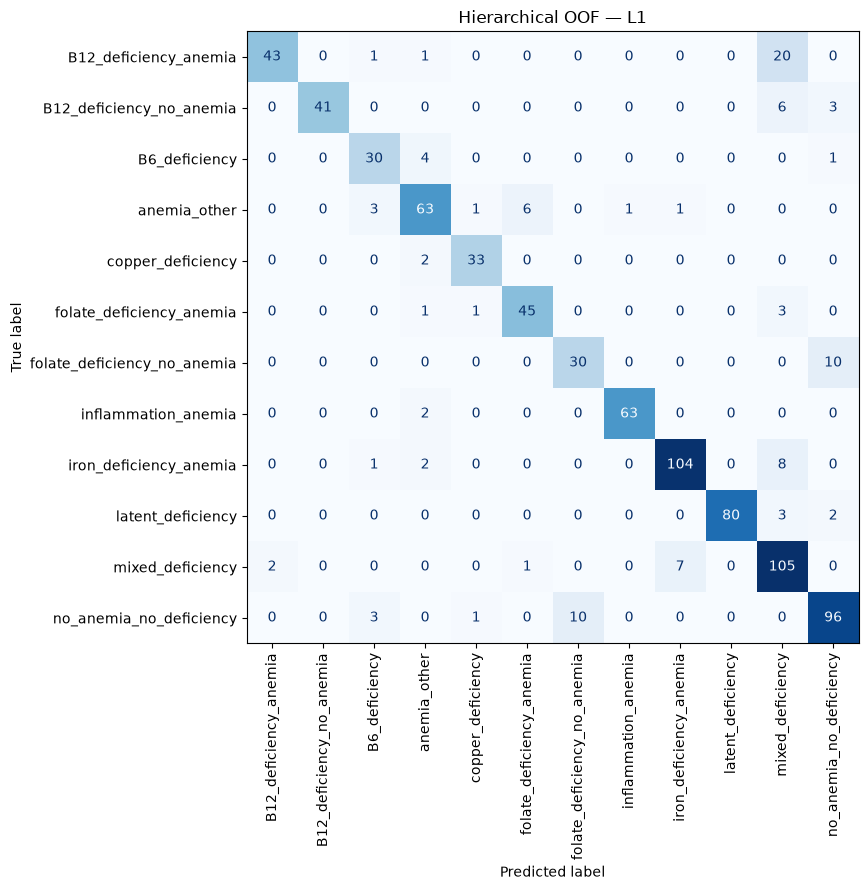

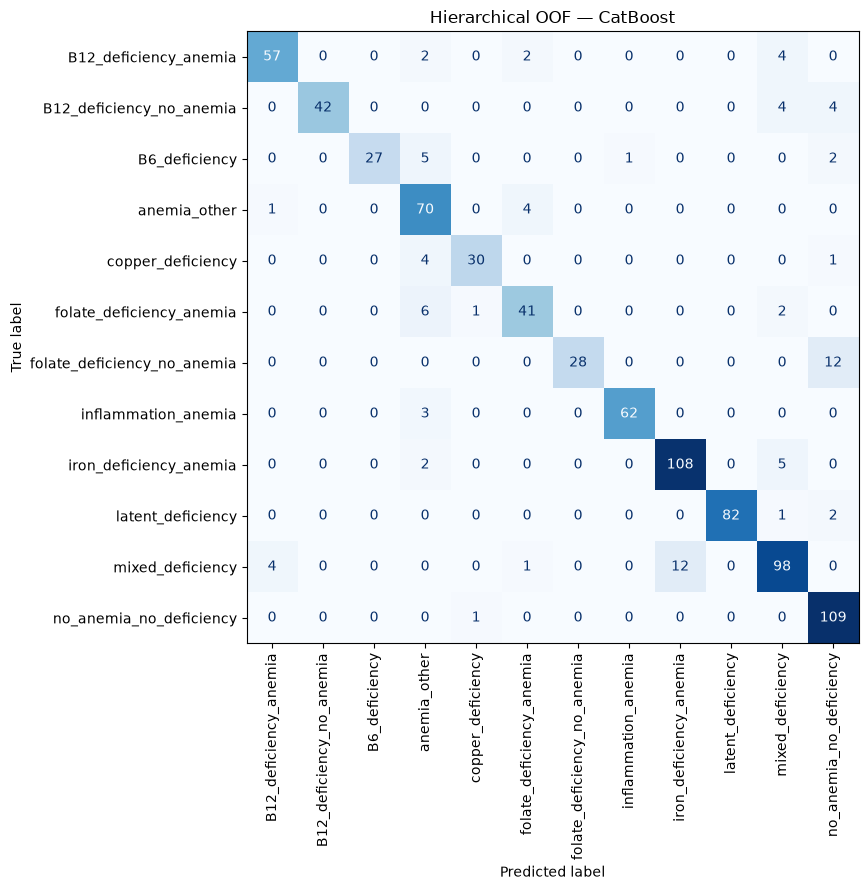

In [19]:

classes = sorted(
    df["anemia_class"].unique()
)

for model_name in [
    "L1",
    "CatBoost",
]:
    fig, ax = plt.subplots(
        figsize=(11, 9)
    )

    ConfusionMatrixDisplay.from_predictions(
        df["anemia_class"],
        hierarchical_predictions[
            model_name
        ]["class"],
        labels=classes,
        xticks_rotation=90,
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )

    ax.set_title(
        f"Hierarchical OOF — "
        f"{model_name}"
    )

    plt.tight_layout()
    plt.show()



## 17. Качество `deficiency_cause`

Это отдельная полезная продуктовая метрика.

Даже если итоговый `anemia_class` иногда ошибается, нам важно понимать, насколько хорошо система определяет предполагаемую причину.


In [20]:

cause_rows = []

for model_name in [
    "L1",
    "CatBoost",
]:
    pred_cause = (
        hierarchical_predictions[
            model_name
        ]["cause"]
    )

    cause_rows.append({
        "model":
            f"hierarchical_{model_name}",
        "macro_f1":
            f1_score(
                df["deficiency_cause"],
                pred_cause,
                average="macro",
                zero_division=0,
            ),
        "accuracy":
            accuracy_score(
                df["deficiency_cause"],
                pred_cause,
            ),
    })

cause_summary = (
    pd.DataFrame(cause_rows)
    .set_index("model")
)

display(cause_summary.round(4))


,macro_f1,accuracy
model,,
hierarchical_L1,0.8526,0.8714
hierarchical_CatBoost,0.8763,0.8964



## 18. Анализ конфликтов бинарных моделей

Иерархическая модель может одновременно считать вероятными состояния, которые не встречались вместе в обучающей разметке.

Например:

```text
iron >= 0.5
copper >= 0.5
```

Считаем, насколько часто это происходит.

Если конфликтов много — это дополнительный аргумент в пользу rule layer.


In [21]:

def count_positive_targets(
    storage,
    threshold=0.5,
):
    matrix = np.column_stack([
        (
            storage[target]
            >= threshold
        ).astype(int)
        for target in DEFICIENCY_TARGETS
    ])

    return matrix.sum(axis=1)


conflict_rows = []

for model_name, storage in [
    ("L1", oof_l1),
    ("CatBoost", oof_catboost),
]:
    positive_count = (
        count_positive_targets(
            storage,
        )
    )

    conflict_rows.append({
        "model": model_name,
        "patients_zero_positive":
            int((positive_count == 0).sum()),
        "patients_one_positive":
            int((positive_count == 1).sum()),
        "patients_two_or_more":
            int((positive_count >= 2).sum()),
        "max_positive_targets":
            int(positive_count.max()),
    })

display(
    pd.DataFrame(conflict_rows)
)


,model,patients_zero_positive,patients_one_positive,patients_two_or_more,max_positive_targets
0,L1,187,488,165,3
1,CatBoost,221,499,120,3



## 19. Сохраняем OOF probabilities

На следующем этапе они понадобятся для:

1. calibration;
2. подбора порогов;
3. weighted ensemble;
4. rule-based слоя;
5. анализа confidence.


In [22]:

ARTIFACT_DIR = Path(
    "../artifacts/hierarchical"
)

if not ARTIFACT_DIR.parent.exists():
    ARTIFACT_DIR = Path(
        "artifacts/hierarchical"
    )

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

export = pd.DataFrame({
    "patient_id":
        df[ID_COLUMN],
    "anemia_rule":
        df["anemia_rule"],
    "true_class":
        df["anemia_class"],
    "true_cause":
        df["deficiency_cause"],
})

for target in DEFICIENCY_TARGETS:
    export[
        f"L1__{target}__proba"
    ] = oof_l1[target]

    export[
        f"CatBoost__{target}__proba"
    ] = oof_catboost[target]

for model_name in [
    "L1",
    "CatBoost",
]:
    export[
        f"hierarchical_{model_name}__class"
    ] = (
        hierarchical_predictions[
            model_name
        ]["class"]
    )

    export[
        f"hierarchical_{model_name}__cause"
    ] = (
        hierarchical_predictions[
            model_name
        ]["cause"]
    )

export.to_csv(
    ARTIFACT_DIR
    / "hierarchical_oof_predictions.csv",
    index=False,
)

overall_binary_summary.to_csv(
    ARTIFACT_DIR
    / "binary_target_metrics.csv",
    index=False,
)

hierarchical_class_summary.to_csv(
    ARTIFACT_DIR
    / "hierarchical_class_metrics.csv",
)

cause_summary.to_csv(
    ARTIFACT_DIR
    / "hierarchical_cause_metrics.csv",
)

pd.DataFrame(
    l1_best_c_rows
).to_csv(
    ARTIFACT_DIR
    / "l1_best_c.csv",
    index=False,
)

print(
    "Результаты сохранены:",
    ARTIFACT_DIR.resolve(),
)


Результаты сохранены: /home/sinopah/meditron/notebooks/artifacts/hierarchical



# 20. Что делаем после этого

После выполнения этого ноутбука у нас будет:

- deterministic `anemia`;
- OOF вероятности каждого дефицита;
- две иерархические модели:
  - L1;
  - CatBoost;
- OOF качество итогового `anemia_class`;
- OOF качество `deficiency_cause`.

Следующий этап:

## `04_rules_calibration_ensemble.ipynb`

В нём:

1. добавим clinical rule layer;
2. зафиксируем медицинские пороги только из подтверждённых источников;
3. откалибруем L1/CatBoost probabilities;
4. подберём бинарные thresholds **только внутри training data**;
5. построим weighted ensemble:
   - calibrated L1;
   - calibrated CatBoost;
   - clinical rules;
6. сравним ensemble с:
   - direct `L1_full`;
   - hierarchical L1;
   - hierarchical CatBoost;
7. отдельно проверим missingness robustness.

После этого уже имеет смысл подключать внешний датасет и проверять transfer/generalization.
